# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [159]:
data = pd.read_csv("titanic.csv")

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [160]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [161]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [162]:
data.describe

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [163]:
# Check Missing Value
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [164]:
# Check duplicate
data.duplicated().sum()

np.int64(0)

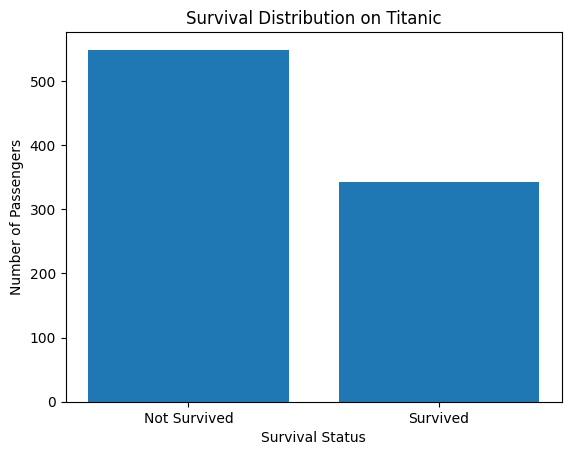

In [165]:
# Survival Distribution
survival_counts = data['Survived'].value_counts().sort_index()

# plot
plt.figure()
plt.bar(survival_counts.index, survival_counts.values)
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.title('Survival Distribution on Titanic')
plt.show()

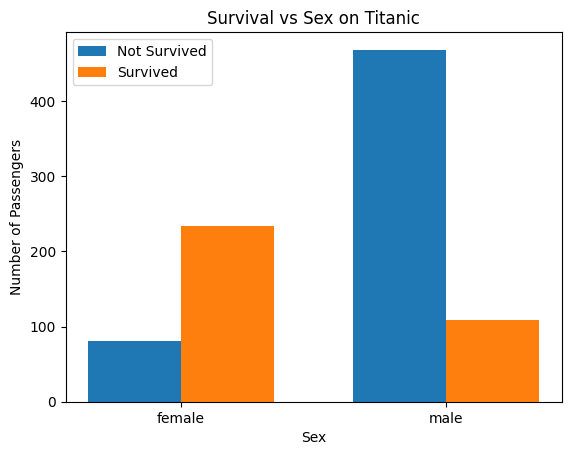

In [166]:
# Survival vs Sex
sex_survival = data.groupby(['Sex', 'Survived']).size().unstack()

labels = sex_survival.index
not_survived = sex_survival[0]
survived = sex_survival[1]

x = np.arange(len(labels))
width = 0.35

# plot
plt.figure()
plt.bar(x - width/2, not_survived, width, label='Not Survived')
plt.bar(x + width/2, survived, width, label='Survived')

plt.xticks(x, labels)
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.title('Survival vs Sex on Titanic')
plt.legend()
plt.show()

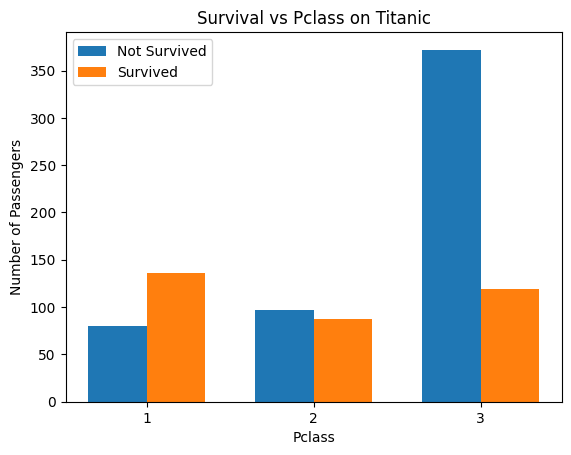

In [167]:
# Survival vs Pclass

pclass_survival = data.groupby(['Pclass', 'Survived']).size().unstack()

labels = pclass_survival.index
not_survived = pclass_survival[0]
survived = pclass_survival[1]

x = np.arange(len(labels))
width = 0.35

# plot
plt.figure()
plt.bar(x - width/2, not_survived, width, label='Not Survived')
plt.bar(x + width/2, survived, width, label='Survived')

plt.xticks(x, labels)
plt.xlabel('Pclass')
plt.ylabel('Number of Passengers')
plt.title('Survival vs Pclass on Titanic')
plt.legend()
plt.show()

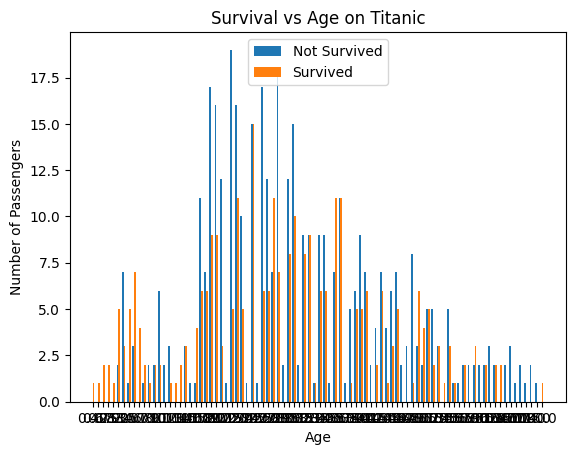

In [168]:
# Age vs Survived

age_survival = data.groupby(['Age', 'Survived']).size().unstack()

labels = age_survival.index
not_survived = age_survival[0]
survived = age_survival[1]

x = np.arange(len(labels))
width = 0.35

# plot
plt.figure()
plt.bar(x - width/2, not_survived, width, label='Not Survived')
plt.bar(x + width/2, survived, width, label='Survived')

plt.xticks(x, labels)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Survival vs Age on Titanic')
plt.legend()
plt.show()

In [169]:
# Binning Age

age_bins = [0, 12, 18, 35, 60, 80]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=age_bins,
    labels=age_labels
)

agegroup_table = data['AgeGroup'].value_counts().sort_index().reset_index()
agegroup_table.columns = ['AgeGroup', 'Count']
agegroup_table


,AgeGroup,Count
0,Child,69
1,Teen,70
2,Young Adult,358
3,Adult,195
4,Senior,22


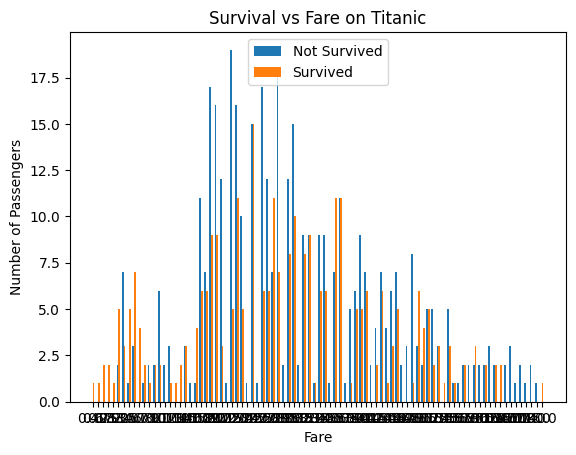

In [170]:
# Fare vs Survived
fare_survival = data.groupby(['Age', 'Survived']).size().unstack()

labels = fare_survival.index
not_survived = fare_survival[0]
survived = fare_survival[1]

x = np.arange(len(labels))
width = 0.35

# plot
plt.figure()
plt.bar(x - width/2, not_survived, width, label='Not Survived')
plt.bar(x + width/2, survived, width, label='Survived')

plt.xticks(x, labels)
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.title('Survival vs Fare on Titanic')
plt.legend()
plt.show()


In [171]:
# Binning Fare
data['FareGroup'] = pd.qcut(
    data['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

faregroup_table = data['FareGroup'].value_counts().sort_index().reset_index()
faregroup_table.columns = ['FareGroup', 'Count']
faregroup_table

,FareGroup,Count
0,Low,223
1,Medium,224
2,High,222
3,Very High,222


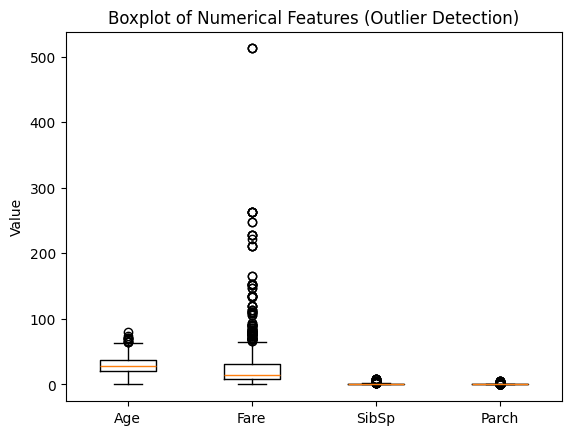

In [172]:
# Detect Outlier
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure()
plt.boxplot([data[col].dropna() for col in num_features])
plt.xticks(range(1, len(num_features) + 1), num_features)
plt.ylabel('Value')
plt.title('Boxplot of Numerical Features (Outlier Detection)')
plt.show()



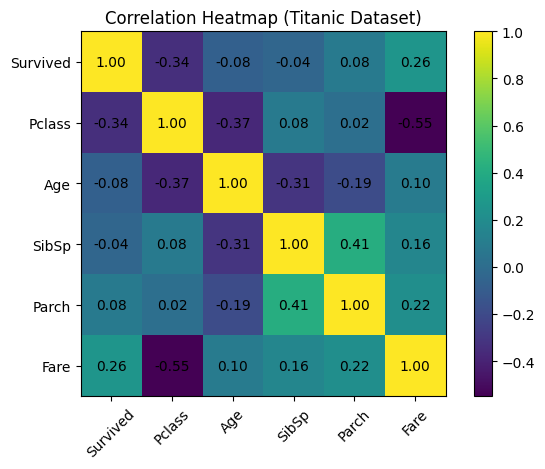

In [173]:
# Correlation Heatmap

numerical_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = data[numerical_features].corr()

plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

ticks = np.arange(len(numerical_features))
plt.xticks(ticks, numerical_features, rotation=45)
plt.yticks(ticks, numerical_features)

# add correlation values
for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title('Correlation Heatmap (Titanic Dataset)')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [174]:
# Handling Missing Value
data = data.dropna()

# Check missing value after drop
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
AgeGroup       0
FareGroup      0
dtype: int64

In [175]:
# Drop duplicate
data = data.drop_duplicates()

# Check duplicate after drop
data.duplicated().sum()

np.int64(0)

In [176]:
# Normalisasi
scaler = MinMaxScaler()
data[num_features] = scaler.fit_transform(data[num_features])

In [177]:
# Encoding
cat_features = ['Sex', 'Embarked', 'Pclass']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(data[cat_features])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_features)
)

df = pd.concat([data.drop(columns=cat_features), encoded_df], axis=1)

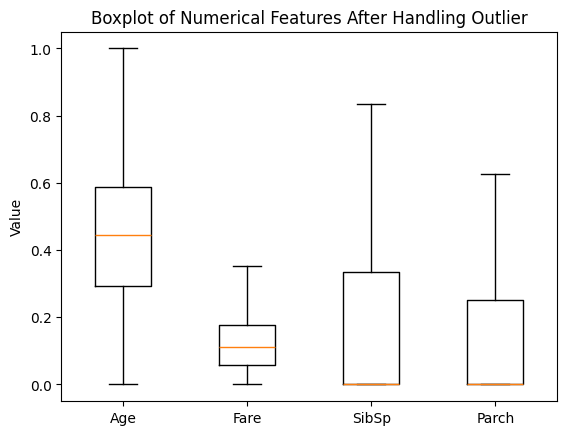

In [178]:
# Handling Outlier

def handle_outliers_all_numeric_iqr(data):
    numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        # skip target
        if col == 'Survived':
            continue

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data[col] = data[col].clip(lower=lower, upper=upper)

    return data

data = handle_outliers_all_numeric_iqr(data)

# Cek after handling outlier

num_features = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure()
plt.boxplot([data[col].dropna() for col in num_features])
plt.xticks(range(1, len(num_features) + 1), num_features)
plt.ylabel('Value')
plt.title('Boxplot of Numerical Features After Handling Outlier')
plt.show()


In [180]:
# Split Dataset

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)